# **Revenue Manager's Analysis**

## Objectives

* Answer any unresolved queries coming from the [data collection](/jupyter_notebooks/01_data_collection.ipynb) and [EDA](/jupyter_notebooks/02_cancellation_eda.ipynb) notebooks from the "clients" perspective as though collaborative discussion had occurred.

## Inputs

* outputs/datasets/collection/HotelBookings.csv

## Additional Comments

* This is a supplementary notebook drawing on professional experience to inform cleaning & engineering decisions
* I read the notes on the dataset available on [sciencedirect.com](https://www.sciencedirect.com/science/article/pii/S2352340918315191?via%3Dihub) to learn more about the data provenance and quality.
* Deposit types are described as being categorical, calculated based on the value of the payments identified for the booking in the transaction table *prior* to the bookings arrival or cancellation date. Fully pre-paid bookings are classified as Non Refund, unpaid bookings are No Deposit and partial payments are classified Refundable. 
* It is not clarified whether the transaction table was ever updated on or after the cancellation date so for the purposes of this project, the working assumption is that Non Refund bookings are paid in full.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [20]:
import os
current_dir = os.getcwd()
current_dir

'/home/niall/PP4/cancel-protect'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [21]:
os.chdir(os.path.dirname(current_dir))

current_dir = os.getcwd()
current_dir

'/home/niall/PP4'

## Load Dataframe

In [22]:
import pandas as pd

df = pd.read_csv("outputs/datasets/collection/HotelBookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
2,Resort Hotel,0,7,2023,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02
3,Resort Hotel,0,13,2023,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2023-07-02
4,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2023-07-03


---

## Questions awaiting clarification

Q1. Are the duplicate bookings true accidental duplicates, group bookings or coincidental duplicates? <br>
Q2. Can you clarify the nature of the extreme ouliers: bookings with no adults, max values of 10 for children and babies, 8 car parking spaces and the min and max values for ADR?<br>
Q3. Assess missing data in the company, agent and country variables. 

---

## 1. Duplicate Bookings

**1.1 Create duplicates dataframe**

In [23]:
duplicate_df = df[df.duplicated(keep=False)]
duplicate_df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2023-07-03
5,Resort Hotel,0,14,2023,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2023-07-03
21,Resort Hotel,0,72,2023,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2023-07-07
22,Resort Hotel,0,72,2023,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2023-07-07
39,Resort Hotel,0,70,2023,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2023-07-07
43,Resort Hotel,0,70,2023,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2023-07-07
132,Resort Hotel,1,5,2023,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2023-07-01
138,Resort Hotel,1,5,2023,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2023-07-01
198,Resort Hotel,0,0,2023,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2023-07-08
200,Resort Hotel,0,0,2023,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2023-07-08


**1.2 Test for group bookings**

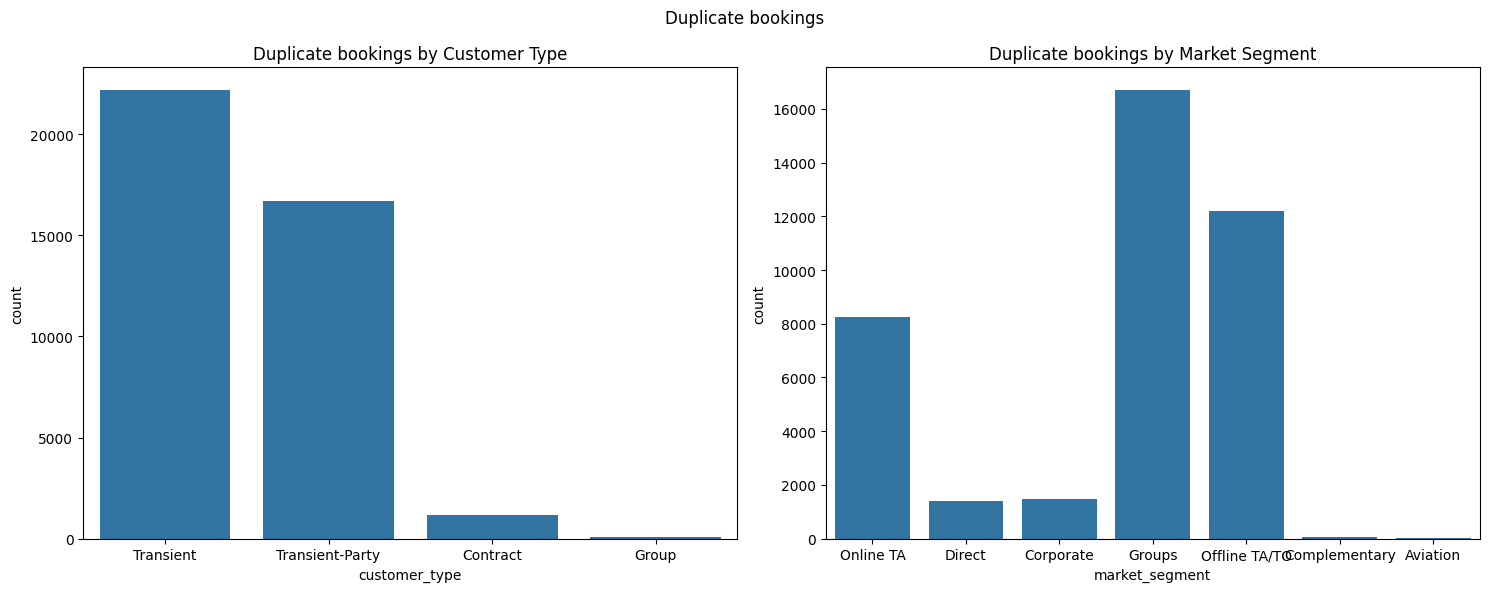

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Duplicate bookings")
ax1.set_title("Duplicate bookings by Customer Type")
ax2.set_title("Duplicate bookings by Market Segment")

sns.countplot(data=duplicate_df,
              x="customer_type",
              ax=ax1)

sns.countplot(data=duplicate_df,
              x="market_segment",
              ax=ax2)

plt.tight_layout()
plt.show()

<Axes: xlabel='customer_type', ylabel='market_segment'>

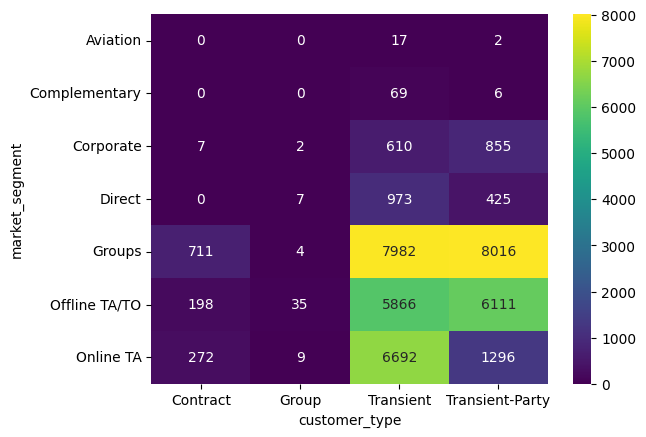

In [25]:
bkg_type = pd.crosstab(duplicate_df["market_segment"], duplicate_df["customer_type"])
sns.heatmap(bkg_type, annot=True, fmt="d", cmap="viridis")

In [26]:
all_groups = (
    (duplicate_df["customer_type"].isin(["Group", "Transient-Party"])) | 
    (duplicate_df["market_segment"] == "Groups")
)

proportion = all_groups.mean()
count = all_groups.sum()

proportion, count

(np.float64(0.6339101207518985), np.int64(25461))

In [27]:
criteria = pd.DataFrame({
    "ct_group": duplicate_df["customer_type"].isin(["Group", "Transient-Party"]),
    "ms_group": duplicate_df["market_segment"] == "Groups"
})

criteria["overlap"] = criteria.sum(axis=1)
criteria["overlap"].value_counts().sort_index()

overlap
0    14704
1    17441
2     8020
Name: count, dtype: int64

* The majority (63%) of duplicated rows are associated with the "Groups" market_segment or "Transient-Party" customer_type, both of which generate genuine repeated bookings (multiple rooms booked together for a family, party, or group). This provides a credible explanation for the bulk of the duplicate set.
* *The possibility of hotel staff user error cannot be completely ruled out for individual cases. However, this type of error is expected to persist in live hotel data, so any predictive model should be built to tolerate it rather than assume a fully deduplicated feed.*

**1.3 Assess index deltas of duplicates to look for large clusters that might suggest database batch export errors**

In [28]:
cols = duplicate_df.columns.to_list()

deltas = (duplicate_df
          .groupby(cols, dropna=False)
          .apply(lambda x: pd.Series(x.index).diff().dropna(), include_groups=False)
          .reset_index(drop=True)
          .rename("index_delta"))

deltas.head(10)

0       30.0
1       17.0
2        1.0
3        1.0
4        6.0
5        3.0
6    35776.0
7        2.0
8    35499.0
9        4.0
Name: index_delta, dtype: float64

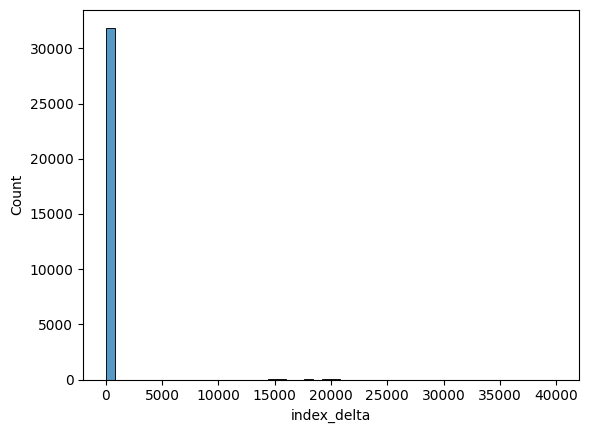

In [29]:
chart = sns.histplot(deltas, bins=50)
plt.show(chart)

* This does show that the duplicates are clustered but the bins are far too wide to be meaningful.

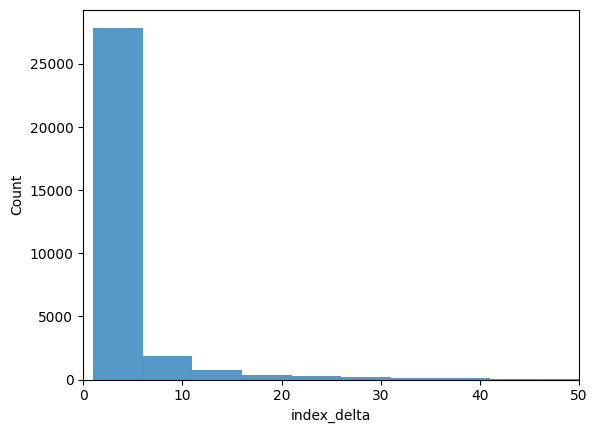

In [30]:
chart = sns.histplot(deltas, bins=8000)
chart.set_xlim(0, 50)
plt.show(chart)

In [31]:
deltas_df = pd.DataFrame({
    "bucket": ["1-2", "3-5", "6-10", "11-20", "21-50", "51-100", "100+"],
    "count": [
        (deltas <= 2).sum(),
        ((deltas > 2) & (deltas <= 5)).sum(),
        ((deltas > 5) & (deltas <= 10)).sum(),
        ((deltas > 10) & (deltas <= 20)).sum(),
        ((deltas > 20) & (deltas <= 50)).sum(),
        ((deltas > 51) & (deltas <= 100)).sum(),
        (deltas > 100).sum(),
    ]
})

deltas_df

,bucket,count
0,1-2,22902
1,3-5,4269
2,6-10,2291
3,11-20,1328
4,21-50,863
5,51-100,188
6,100+,143


* This doesn't really give me the conclusive information required. Large clusters will all have small index deltas.

**1.4 Assess cluster size**

In [32]:
duplicates = (duplicate_df
            .groupby(cols, dropna=False)
            .size()
            .reset_index(name="duplicate_count"))

duplicates

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,duplicate_count
0,City Hotel,0,0,2023,August,32,7,0,2,2,...,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2023-08-09,2
1,City Hotel,0,0,2023,August,32,8,0,1,2,...,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2023-08-09,2
2,City Hotel,0,0,2023,August,33,10,1,0,2,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2023-08-11,3
3,City Hotel,0,0,2023,August,33,11,0,1,1,...,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2023-08-12,2
4,City Hotel,0,0,2023,August,33,11,0,1,2,...,NaN,NaN,0,Transient,80.0,0,0,Check-Out,2023-08-12,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8166,Resort Hotel,1,462,2025,May,21,25,0,3,2,...,NaN,NaN,0,Transient,78.0,0,0,Canceled,2024-06-07,20
8167,Resort Hotel,1,468,2024,May,20,12,0,2,1,...,249.0,NaN,0,Transient-Party,0.0,0,0,Canceled,2023-07-30,2
8168,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,249.0,NaN,0,Transient-Party,67.0,0,0,Canceled,2024-03-04,8
8169,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,249.0,NaN,0,Transient-Party,67.0,0,0,Canceled,2023-07-30,18


In [33]:
duplicates["duplicate_count"].min(), duplicates["duplicate_count"].max()

(np.int64(2), np.int64(180))

* The maximum value of 180 identical duplicate rows is significant. While user error is a possible explanation, it does warrant further investigation

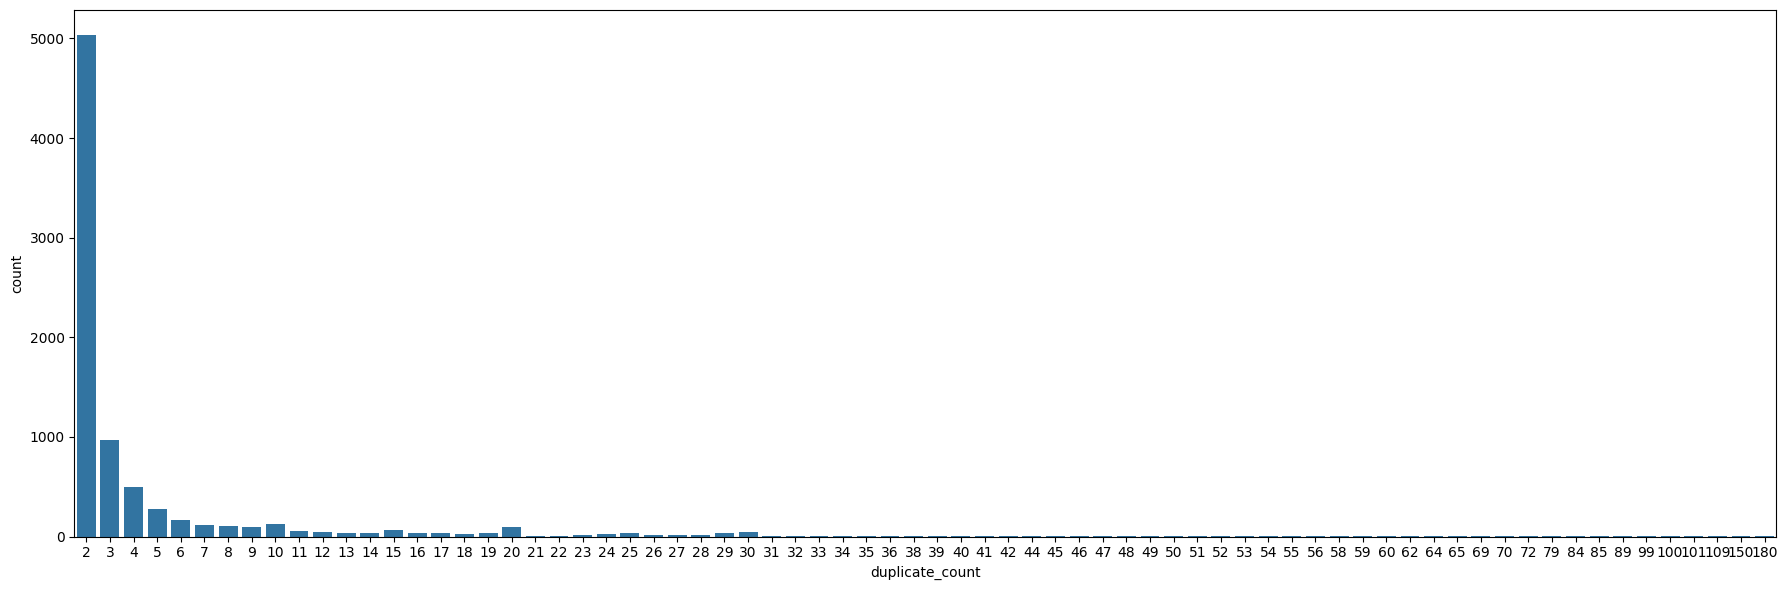

In [34]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.countplot(data=duplicates,
            x="duplicate_count",
            ax=ax)
plt.tight_layout()
plt.show()

* I believe we are dealing with a mix of genuine duplicates and erroneous duplicates.
* Erroneous duplicates could be user input error or database batching error, or a mix of both. 

**1.5 Combine cluster and index delta to identify large adjacent clusters**

In [35]:
def adjacent_clusters(cluster_index):
    idx = pd.Series(sorted(cluster_index))

    breaks = (idx.diff() != 1).cumsum()
    return idx.groupby(breaks).size()

cluster_sizes = (duplicate_df
                 .groupby(cols, dropna=False)
                 .apply(lambda x: adjacent_clusters(x.index), include_groups=False)
                 .reset_index(name="cluster_size"))
cluster_sizes

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,level_32,cluster_size
0,City Hotel,0,0,2023,August,32,7,0,2,2,...,NaN,0,Transient,75.0,0,1,Check-Out,2023-08-09,1,1
1,City Hotel,0,0,2023,August,32,7,0,2,2,...,NaN,0,Transient,75.0,0,1,Check-Out,2023-08-09,2,1
2,City Hotel,0,0,2023,August,32,8,0,1,2,...,NaN,0,Transient,89.0,0,1,Check-Out,2023-08-09,1,1
3,City Hotel,0,0,2023,August,32,8,0,1,2,...,NaN,0,Transient,89.0,0,1,Check-Out,2023-08-09,2,1
4,City Hotel,0,0,2023,August,33,10,1,0,2,...,NaN,0,Transient,75.0,0,0,Check-Out,2023-08-11,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20719,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,NaN,0,Transient-Party,67.0,0,0,Canceled,2024-03-04,4,3
20720,Resort Hotel,1,468,2024,May,20,12,0,2,2,...,NaN,0,Transient-Party,67.0,0,0,Canceled,2023-07-30,1,18
20721,Resort Hotel,1,471,2025,May,20,20,2,5,2,...,NaN,0,Transient,47.0,0,0,Canceled,2025-05-03,1,1
20722,Resort Hotel,1,471,2025,May,20,20,2,5,2,...,NaN,0,Transient,47.0,0,0,Canceled,2025-05-03,2,2


In [36]:
cluster_sizes["cluster_size"].min(), cluster_sizes["cluster_size"].max(), cluster_sizes["cluster_size"].mean()

(np.int64(1), np.int64(150), np.float64(1.938091102103841))

* 150 adjacent identical rows is another significant finding. 

In [37]:
cluster_sizes.sort_values("cluster_size", ascending=False)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,level_32,cluster_size
10642,City Hotel,1,68,2024,February,8,17,0,2,2,...,NaN,0,Transient,75.0,0,0,Canceled,2024-01-06,1,150
9735,City Hotel,1,34,2023,December,50,8,0,2,1,...,NaN,0,Transient,90.0,0,0,Canceled,2023-11-17,1,100
15112,City Hotel,1,342,2023,September,39,24,2,4,2,...,NaN,0,Transient,170.0,0,0,Canceled,2023-08-21,1,72
14750,City Hotel,1,301,2023,August,33,14,0,2,2,...,NaN,0,Transient-Party,101.5,0,0,Canceled,2023-07-06,1,70
11456,City Hotel,1,99,2024,February,8,19,0,1,2,...,67.0,0,Transient-Party,80.0,0,0,Canceled,2023-12-22,1,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7104,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,17,1
7105,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,18,1
7106,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,19,1
7107,City Hotel,0,213,2025,August,35,28,1,3,1,...,NaN,0,Transient-Party,104.0,0,0,Check-Out,2025-09-01,20,1


* Upon inspection, the large clusters (150, 100) appear to be paid in full via an agent.
* There is no evidence that the duplicate data is the result of export error. 

**1.6 Non-refund duplicates**

As discovered in the [cancellation EDA](/jupyter_notebooks/02_cancellation_eda.ipynb) notebook, the overwhelming majority of Non Refund bookings are duplicates.

In [38]:
duplicate_df["deposit_type"].value_counts()



deposit_type
No Deposit    25773
Non Refund    14316
Refundable       76
Name: count, dtype: int64

In [39]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [40]:
df["deposit_type"].value_counts() - duplicate_df["deposit_type"].value_counts()

deposit_type
No Deposit    78868
Non Refund      271
Refundable       86
Name: count, dtype: int64

This seems to make a compelling argument for an error, however, we must assume that the hotels' accounts departments would have flagged the errors had the declared payments been missing.

* To fully address this, compare the deposit type to the market segments

In [41]:
deposit_segment = pd.crosstab(duplicate_df["deposit_type"], duplicate_df["market_segment"], normalize="index")
deposit_segment.style.bar(color="darkgreen").format("{:.1%}")

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA
deposit_type,,,,,,,
No Deposit,0.1%,0.3%,4.6%,5.4%,29.6%,28.2%,31.9%
Non Refund,0.0%,0.0%,2.0%,0.1%,63.1%,34.6%,0.3%
Refundable,0.0%,0.0%,2.6%,0.0%,88.2%,0.0%,9.2%


* Here we see 63% of the duplicate non-refundable bookings are in the groups segment and 34.6% in the offline travel agent/tour operator segment both of which regularly book multiple rooms.

## Q1 Conclusions

* The data supports the assumption that group bookings account for the majority of duplicated bookings - 63%
* The remaining 14704 duplicates (12% of total bookings) can be plausibly explained by normal hotel booking behaviour
* Without booking reference or guest ID fields, there is no way to conclusively separate coincidental collisions from export artifacts. The groups and travel agent/tour operator findings account for the substantial majority of duplicates 
* There is nothing in the remaining pattern (cluster sizes, distribution across the file) to suggest systematic duplication rather than normal booking behaviour.
* Staff user error cannot be ruled out, but would be expected to persist

**Revenue Manager's Decision:**

The duplicates are genuine and should remain in place throughout.

---

## 2. Extreme Outliers

**2.1 Bookings with no adults**

In [42]:
no_adults_df = df[df["adults"] == 0]
no_adults_df.shape

(403, 32)

* We can see that there are 403 rows with no adults - not statistically significant over a dataset of 119,390 rows.

In [43]:
no_adults_df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2023,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2023-10-06
2409,Resort Hotel,0,0,2023,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2023-10-12
3181,Resort Hotel,0,36,2023,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2023-11-23
3684,Resort Hotel,0,165,2023,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2024-01-04
3708,Resort Hotel,0,165,2023,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2024-01-05
4127,Resort Hotel,1,0,2024,February,8,15,0,0,0,...,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2024-02-15
9376,Resort Hotel,1,0,2024,November,48,21,0,0,0,...,No Deposit,NaN,386.0,0,Group,0.0,0,0,Canceled,2024-11-21
31765,Resort Hotel,0,31,2024,December,53,27,2,8,0,...,No Deposit,NaN,NaN,0,Transient,28.0,1,0,Check-Out,2025-01-06
32029,Resort Hotel,0,4,2025,January,2,14,0,1,0,...,No Deposit,168.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2025-01-15
32827,Resort Hotel,0,46,2025,January,4,25,3,9,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2025-02-06


* I had expected most of these rows to be bookings for children adjacent their parents, but the first 10 rows reveal no guests at all

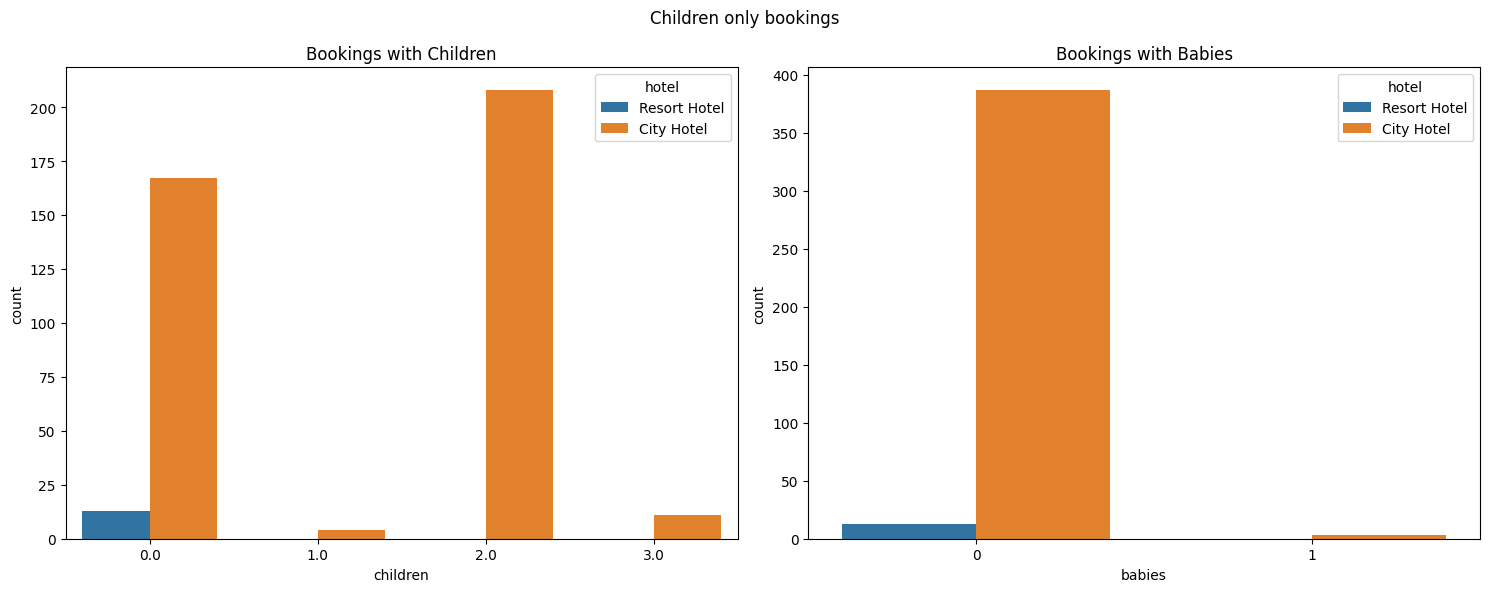

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Children only bookings")
ax1.set_title("Bookings with Children")
ax2.set_title("Bookings with Babies")

sns.countplot(data=no_adults_df,
              x="children",
              hue="hotel",
              ax=ax1)

sns.countplot(data=no_adults_df,
              x="babies",
              hue="hotel",
              ax=ax2)

plt.tight_layout()
plt.show()

In [45]:
((no_adults_df["children"] > 0) | (no_adults_df["babies"] > 0)).sum()

np.int64(223)

* 223 of the rows have either children or babies or both and all in the city hotel. This is likely due to a lack of family sized rooms with interconnecting or adjacent rooms being offered instead.

In [46]:
no_guests = no_adults_df[((no_adults_df["children"] == 0) & (no_adults_df["babies"] == 0))]
no_guests

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2023,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.00,0,0,Check-Out,2023-10-06
2409,Resort Hotel,0,0,2023,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.00,0,0,Check-Out,2023-10-12
3181,Resort Hotel,0,36,2023,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.00,0,0,Check-Out,2023-11-23
3684,Resort Hotel,0,165,2023,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,2024-01-04
3708,Resort Hotel,0,165,2023,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,2024-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2025,June,26,27,0,3,0,...,No Deposit,7.0,NaN,0,Transient,100.80,0,0,Check-Out,2025-06-30
115091,City Hotel,0,1,2025,June,26,30,0,1,0,...,No Deposit,NaN,NaN,0,Transient,0.00,1,1,Check-Out,2025-07-01
116251,City Hotel,0,44,2025,July,28,15,1,1,0,...,No Deposit,425.0,NaN,0,Transient,73.80,0,0,Check-Out,2025-07-17
116534,City Hotel,0,2,2025,July,28,15,2,5,0,...,No Deposit,9.0,NaN,0,Transient-Party,22.86,0,1,Check-Out,2025-07-22


In [47]:
no_guests.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.0,180.0,180.0,180.000000,180.000000,180.000000,180.000000,120.000000,29.000000,180.000000,180.000000,180.000000,180.000000
mean,0.138889,39.233333,2024.211111,28.355556,15.483333,1.288889,3.233333,0.0,0.0,0.0,0.305556,0.038889,0.138889,1.761111,51.883333,230.310345,2.277778,10.456500,0.038889,0.477778
std,0.346795,74.156192,0.701068,16.054593,8.638277,2.348157,5.608354,0.0,0.0,0.0,0.461927,0.244810,0.926119,3.146984,90.688143,142.639932,15.310221,31.681635,0.193869,0.735801
min,0.000000,0.000000,2023.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,38.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2024.000000,12.000000,7.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,9.000000,153.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,2024.000000,28.000000,15.000000,0.000000,1.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000,14.000000,279.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,38.250000,2025.000000,44.000000,24.000000,2.000000,4.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,2.000000,39.000000,279.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,434.000000,2025.000000,53.000000,31.000000,16.000000,41.000000,0.0,0.0,0.0,1.000000,2.000000,9.000000,21.000000,459.000000,523.000000,122.000000,200.000000,1.000000,3.000000


In [48]:
no_guests["adr"].value_counts().sort_index()

adr
0.00      149
1.00        1
1.29        1
3.38        1
6.00        1
6.40        1
8.00        1
8.34        1
16.92       1
20.88       1
22.86       1
27.69       1
28.00       1
32.85       1
35.81       1
50.87       2
56.27       1
57.30       1
69.50       1
73.80       1
77.53       1
86.40       1
89.20       1
90.00       1
92.67       1
97.40       1
100.80      1
136.46      1
165.38      1
168.30      1
200.00      1
Name: count, dtype: int64

* 180 rows from 119,390 show no guests at all.
* Only 31 of the rows received any payment with the mean adr being €10.45

**Conclusion**

403 rows total had no adults, this is only 0.3% of the total dataset. 223 of these bookings did have children, I suggest they are part of a multi-room booking with adults. This leaves only 180 rows - a statistically insignificant amount - with very low mean adr. This is suggestive of an operational use rather than a strict room booking.

**2.2 Max values of 10 for both children and babies**

In [49]:
with_children_df = df[(df["children"] > 0) | (df["babies"] > 0)]
with_children_df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
13,Resort Hotel,0,18,2023,July,27,1,0,4,2,...,No Deposit,241.0,NaN,0,Transient,154.77,0,1,Check-Out,2023-07-05
45,Resort Hotel,1,47,2023,July,27,2,2,5,2,...,No Deposit,240.0,NaN,0,Transient,153.00,0,0,Canceled,2023-06-02
55,Resort Hotel,0,1,2023,July,27,2,0,1,2,...,No Deposit,NaN,NaN,0,Transient,107.00,1,2,Check-Out,2023-07-03
65,Resort Hotel,0,10,2023,July,27,3,0,2,2,...,No Deposit,240.0,NaN,0,Transient,153.00,1,0,Check-Out,2023-07-05
87,Resort Hotel,1,79,2023,July,27,3,6,15,2,...,No Deposit,242.0,NaN,0,Transient,108.73,0,2,Canceled,2023-04-15
98,Resort Hotel,0,101,2023,July,27,3,2,5,2,...,No Deposit,240.0,NaN,0,Transient,99.30,1,2,Check-Out,2023-07-10
102,Resort Hotel,0,92,2023,July,27,4,2,4,1,...,No Deposit,241.0,NaN,0,Transient,96.49,0,2,Check-Out,2023-07-10
105,Resort Hotel,1,26,2023,July,27,4,2,5,2,...,No Deposit,240.0,NaN,0,Transient,163.00,0,0,Canceled,2023-06-09
109,Resort Hotel,0,102,2023,July,27,4,2,5,2,...,No Deposit,240.0,NaN,0,Transient,73.80,0,2,Check-Out,2023-07-11
111,Resort Hotel,0,78,2023,July,27,4,2,5,2,...,No Deposit,240.0,NaN,0,Transient,139.00,0,2,Check-Out,2023-07-11


In [50]:
with_children_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,9332.000000,8531.000000,91.000000,9332.000000,9332.000000,9332.000000,9332.000000
mean,0.349228,88.547793,2024.284612,27.645628,16.261787,1.106301,2.828976,1.962066,1.329083,0.101693,0.010287,0.007072,0.017895,0.399807,102.579533,231.120879,0.095799,154.434700,0.118838,0.927561
std,0.476752,83.130781,0.661256,12.367125,8.924092,0.996971,1.909232,0.448455,0.635497,0.334571,0.100908,0.087557,0.269957,0.846188,113.689224,151.077231,3.539970,64.470336,0.325926,0.962095
min,0.000000,0.000000,2023.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,19.000000,2024.000000,18.000000,9.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,48.000000,0.000000,109.000000,0.000000,0.000000
50%,0.000000,63.000000,2024.000000,29.000000,17.000000,1.000000,3.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,223.000000,0.000000,148.500000,0.000000,1.000000
75%,1.000000,144.000000,2025.000000,34.000000,24.000000,2.000000,4.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,240.000000,342.000000,0.000000,195.000000,0.000000,2.000000
max,1.000000,424.000000,2025.000000,53.000000,31.000000,8.000000,22.000000,4.000000,10.000000,10.000000,1.000000,2.000000,14.000000,17.000000,527.000000,525.000000,174.000000,451.500000,2.000000,5.000000


* With the mean and 75th percentile for both these features being <= 2, it suggests that the high maximums are indeed extreme outliers

In [51]:
many_children_df =  df[(df["children"] > 4) | (df["babies"] > 4)]
many_children_df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
328,Resort Hotel,1,55,2023,July,29,12,4,10,2,...,No Deposit,8.0,NaN,0,Contract,133.16,0,1,No-Show,2023-07-12
46619,City Hotel,0,37,2024,January,3,12,0,2,2,...,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2024-01-14
78656,City Hotel,0,11,2023,October,42,11,2,1,1,...,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2023-10-14


**Conclusion**

These outliers account for only 3 rows total and can be considered user error - the likeliest scenario is a typo.

**2.3 Parking**

In [52]:
with_parking_df = df[df["required_car_parking_spaces"] > 0]
with_parking_df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
25,Resort Hotel,0,78,2023,July,27,1,2,5,2,...,No Deposit,5.0,NaN,0,Transient,63.6,1,0,Check-Out,2023-07-08
29,Resort Hotel,0,99,2023,July,27,1,2,5,2,...,No Deposit,240.0,NaN,0,Transient,87.3,1,1,Check-Out,2023-07-08
53,Resort Hotel,0,3,2023,July,27,2,0,1,2,...,No Deposit,240.0,NaN,0,Transient,88.2,1,0,Check-Out,2023-07-03
54,Resort Hotel,0,1,2023,July,27,2,0,1,2,...,No Deposit,240.0,NaN,0,Transient,147.0,1,0,Check-Out,2023-07-03
55,Resort Hotel,0,1,2023,July,27,2,0,1,2,...,No Deposit,NaN,NaN,0,Transient,107.0,1,2,Check-Out,2023-07-03
61,Resort Hotel,0,5,2023,July,27,2,0,2,2,...,No Deposit,240.0,NaN,0,Transient,135.0,1,2,Check-Out,2023-07-04
65,Resort Hotel,0,10,2023,July,27,3,0,2,2,...,No Deposit,240.0,NaN,0,Transient,153.0,1,0,Check-Out,2023-07-05
75,Resort Hotel,0,3,2023,July,27,3,1,2,2,...,No Deposit,240.0,NaN,0,Transient,90.9,1,0,Check-Out,2023-07-06
78,Resort Hotel,0,72,2023,July,27,3,2,2,2,...,No Deposit,105.0,NaN,0,Transient,110.7,1,0,Check-Out,2023-07-07
89,Resort Hotel,0,9,2023,July,27,3,0,1,2,...,No Deposit,240.0,NaN,0,Transient,98.0,1,2,Check-Out,2023-07-04


In [53]:
with_parking_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,7416.0,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,7416.000000,5458.000000,760.000000,7416.000000,7416.000000,7416.000000,7416.000000
mean,0.0,54.967772,2024.115696,27.315939,16.090076,0.851268,2.306230,1.889293,0.192017,0.022249,0.083333,0.026025,0.415723,0.386866,170.018505,184.257895,0.094930,113.138015,1.006472,0.828614
std,0.0,73.443797,0.682577,14.035226,8.939610,0.939645,1.799361,0.477421,0.524590,0.152890,0.276404,0.301038,2.257148,0.803489,110.177323,131.644096,3.188803,61.902543,0.136268,0.871298
min,0.0,0.000000,2023.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,12.000000,0.000000,0.000000,1.000000,0.000000
25%,0.0,3.000000,2024.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,40.000000,0.000000,67.000000,1.000000,0.000000
50%,0.0,20.000000,2024.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,219.000000,0.000000,100.000000,1.000000,1.000000
75%,0.0,81.000000,2025.000000,38.000000,24.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,240.000000,242.250000,0.000000,150.000000,1.000000,1.000000
max,0.0,406.000000,2025.000000,53.000000,31.000000,9.000000,21.000000,4.000000,3.000000,2.000000,1.000000,11.000000,57.000000,10.000000,508.000000,539.000000,142.000000,508.000000,8.000000,5.000000


* With the mean and 75th percentile for both these features being ~=1, it suggests that the high maximum is indee dan extreme outlier

In [54]:
many_parking_df = df[df["required_car_parking_spaces"] > 2]
many_parking_df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
29045,Resort Hotel,0,26,2025,March,11,14,0,5,2,...,No Deposit,NaN,NaN,0,Transient-Party,40.00,8,1,Check-Out,2025-03-19
29046,Resort Hotel,0,138,2025,March,12,19,2,2,2,...,No Deposit,NaN,NaN,122,Transient-Party,80.00,8,0,Check-Out,2025-03-23
38117,Resort Hotel,0,205,2025,June,26,26,3,10,2,...,No Deposit,250.0,NaN,0,Transient,111.00,3,0,Check-Out,2025-07-09
102762,City Hotel,0,13,2024,December,50,5,1,0,1,...,No Deposit,9.0,NaN,0,Transient,96.00,3,0,Check-Out,2024-12-06
110812,City Hotel,0,30,2025,April,17,29,2,1,2,...,No Deposit,9.0,NaN,0,Transient-Party,153.33,3,2,Check-Out,2025-05-02


**Conclusion**

These outliers account for only 5 rows total and can be considered user error. Each room has only 2 adults booked - the likeliest scenario is a typo.

**2.4 ADR**

In [55]:
df["adr"].describe()


count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

* Test to see if the abnormally high value(s) is attached to a particular room type (such as bridal suite)

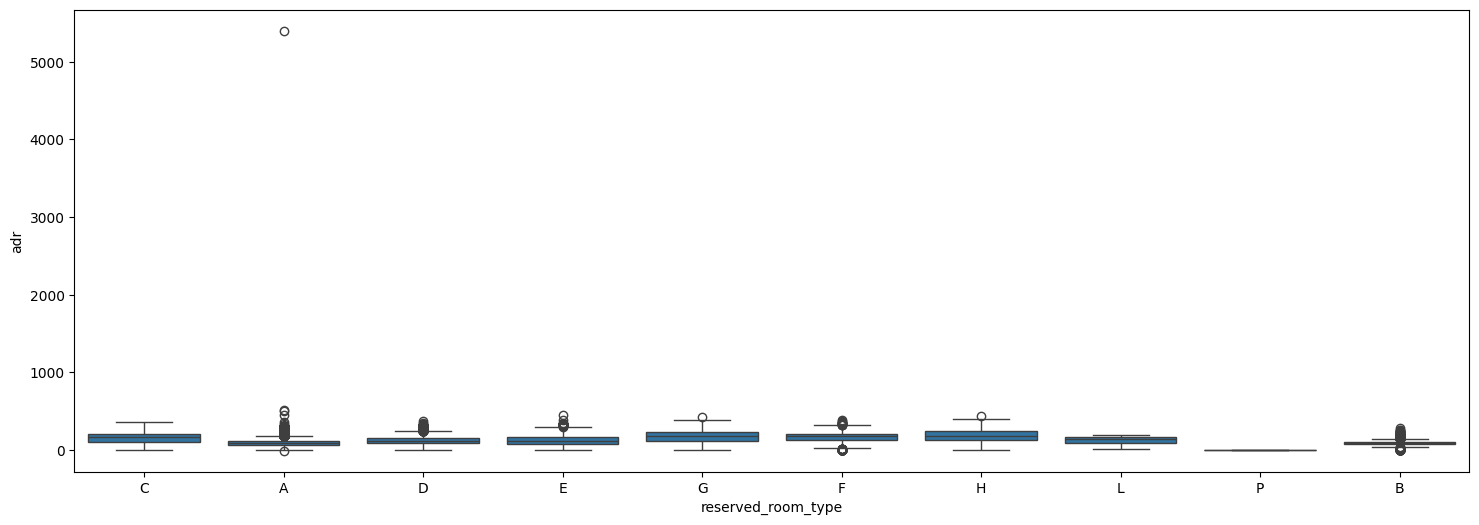

In [56]:
fig, ax = plt.subplots(figsize=(18, 6))
sns.boxplot(data=df,
                x="reserved_room_type",
                y="adr",
                ax=ax)

plt.show()

* The extreme high adr value is indeed an extreme and is significantly isolated from all other values.

* To analyse the lower end anomalies, I will set the upper bound at 35.00 (roughly half the 25th percentile)

In [57]:
low_adr = df[df["adr"] <= 35]
low_adr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
1,Resort Hotel,0,737,2023,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-01
125,Resort Hotel,0,32,2023,July,27,4,0,1,4,...,No Deposit,NaN,NaN,0,Transient,0.0,0,1,Check-Out,2023-07-05
167,Resort Hotel,0,111,2023,July,28,6,0,0,2,...,No Deposit,240.0,NaN,0,Transient,0.0,0,2,Check-Out,2023-07-06
168,Resort Hotel,0,0,2023,July,28,6,0,0,1,...,No Deposit,250.0,NaN,0,Transient,0.0,0,0,Check-Out,2023-07-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118861,City Hotel,0,457,2025,August,34,25,0,2,1,...,No Deposit,6.0,NaN,0,Transient-Party,23.0,0,1,Check-Out,2025-08-27
118963,City Hotel,0,1,2025,August,35,27,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2025-08-27
119102,City Hotel,0,518,2025,August,34,26,2,1,1,...,No Deposit,229.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2025-08-29
119124,City Hotel,0,0,2025,August,35,29,0,1,1,...,No Deposit,NaN,72.0,0,Transient,0.0,0,2,Check-Out,2025-08-30


In [58]:
low_adr["adr"].nunique()

234

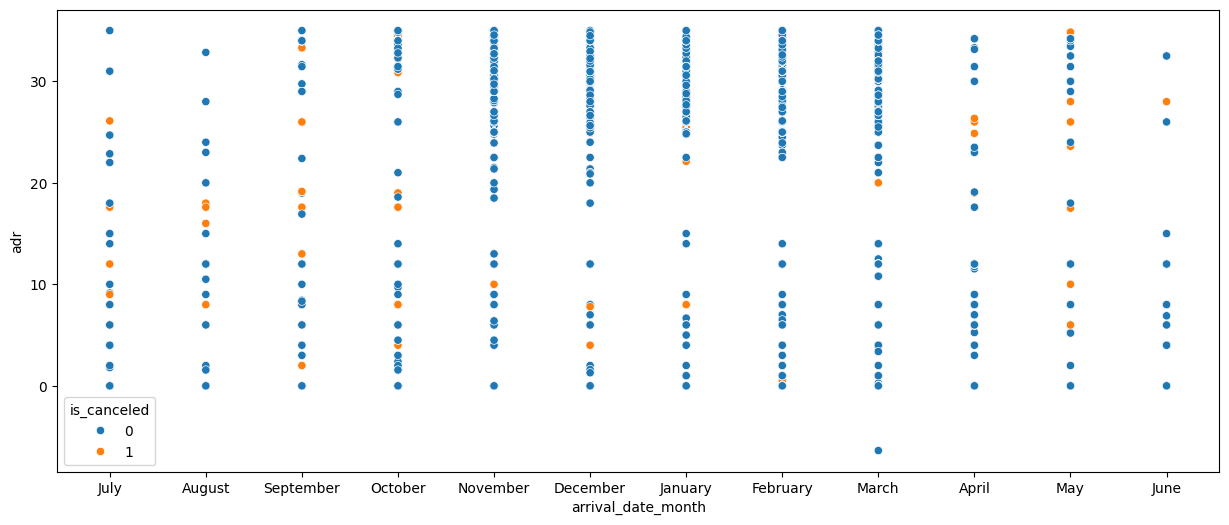

In [59]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.scatterplot(data=low_adr,
                x="arrival_date_month",
                y="adr",
                hue="is_canceled",
                ax=ax)

plt.show()

* The upper half of this plot demonstrates genuine low rated bookings potentially from low yielding discount platforms demonstrated by higher concentrations November through March.
* The lower half seems to show complimentary or partially refunded bookings
* Negative adr values are not especially uncommon in hospitality settings (due to package item allocations such as breakfast or dinner being deducted from complimentary rooms) but to only have a single negative value suggests that this is not the case in either of these properties and suggests a refund beyond the total cost or an instance or user error. 

## Q2 Conclusions

**By their nature, outliers represent statistically insignificant amounts of data but should not necessarily be overlooked entirely**
* 2.1 Of the 403 total rows without adults, 180 contained no guests at all. With a mean adr of 10.45, these are suggestive of an operational mechanism rather than genuine bookings and can be removed.
* 2.2 There were 3 rows total with 9 and 10 babies and children. These are almost certainly typos and can be replaced with 0.
* 2.3 Five rows had more than 2 required car parking spaces, all of which had only 2 occupants. Given the small amount of data and the liklihood of user error, these can also be replaced with 0.
* 2.4 The extreme high outlier was indeed an extreme and isolated value, suggestion is to remove. The negative value is also isolated within the dataset, if not necessarily within the industry, suggestion is to remove also. The remaining low end tail should remain as is demonstrates genuine behaviour.

---